# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Проведение и анализ А/В-тестирования в приложении yandex_knigi.

- Автор:Севрюкова В.Ю.
- Дата:

## Цели и задачи проекта

Цель: определить, действительно ли среднее время активности пользователей в Санкт-Петрбурге больше (время чтения и прослушивание книг в приложении),чем в Москве.  
Задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## Описание данных
Название датасета 'yandex_knigi_data.csv' данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания).

## Содержимое проекта

Основные шаги проекта:

1. Проверить наличие дубликатов в идентификаторах пользователей.
2. Сравните размеры групп, их статистики и распределение.
3. Статистически доказать, используя одностороннюю проверку гипотезы с двумя выборками.
4. Подготовить аналитическую записку.

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Выгружаем данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности
yandex_knigi = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')
print(yandex_knigi.columns.tolist())

['Unnamed: 0', 'city', 'puid', 'hours']


In [3]:
# Выводим на экран первые пять строк полученного датафрейма и убираем столбец Unnamed: 0, т.к. он дублирует позиционный индекс и не несёт смысловой нагрузки
yandex_knigi = yandex_knigi.drop('Unnamed: 0', axis=1, errors='ignore')
yandex_knigi.head(5)

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [4]:
# Информация о столбцах и типах данных
yandex_knigi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB


In [5]:
# Определим наличие и количество дубликатов 
duplicates = yandex_knigi['puid'].duplicated()
duplicates.sum()

244

In [6]:
# Удалим найденные дубликаты
yandex_knigi = yandex_knigi.drop_duplicates(subset=['puid'])

In [7]:
# Проверим количество дубликатов после удаления
yandex_knigi['puid'].duplicated().sum()

0

In [8]:
# Проверка уникальных городов
yandex_knigi['city'].unique()

array(['Москва', 'Санкт-Петербург'], dtype=object)

In [9]:
# Определим размер группы A
moscow_size = yandex_knigi[yandex_knigi['city'] == 'Санкт-Петербург'].shape[0]
moscow_size

2306

In [10]:
# Определим размер группы B
moscow_size = yandex_knigi[yandex_knigi['city'] == 'Москва'].shape[0]
moscow_size

6234

In [11]:
# Проверка распределения по группам
group_distribution = yandex_knigi['city'].value_counts()

display("Распределение по группам:")
display(group_distribution)

display("Доли пользователей в группах:")
display((group_distribution / group_distribution.sum() * 100).round(2))

'Распределение по группам:'

Москва             6234
Санкт-Петербург    2306
Name: city, dtype: int64

'Доли пользователей в группах:'

Москва             73.0
Санкт-Петербург    27.0
Name: city, dtype: float64

Количество пользователей ресурса из Москвы больше, чем из Санкт-Петербурга.

In [12]:
# Определим значения активности (в часах) пользователей из Санкт-Петребурга (группа А)
spb =yandex_knigi.loc[yandex_knigi['city'] == 'Санкт-Петербург', 'hours']

In [13]:
# Определим значения активности (в часах) пользователей из Москвы (группа В)
moscow = yandex_knigi.loc[yandex_knigi['city'] == 'Москва', 'hours']

In [14]:
# Проверяем размеры выборок
display("Размеры выборок:")
display(f"СПб: {len(spb)}")
display(f"Москва: {len(moscow)}")

'Размеры выборок:'

'СПб: 2306'

'Москва: 6234'

In [15]:
# Статистика
display("\nСтатистика по Санкт-Петербургу:")
display(spb.describe())
display("\nСтатистика по Москве:")
display(moscow.describe())

'\nСтатистика по Санкт-Петербургу:'

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

'\nСтатистика по Москве:'

count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

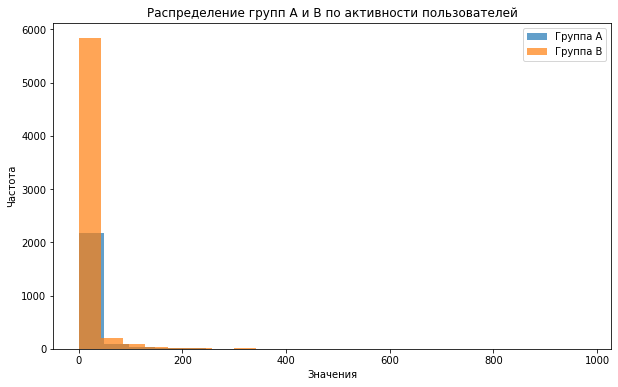

In [16]:
group_a = yandex_knigi.loc[yandex_knigi['city'] == 'Санкт-Петербург', 'hours']
group_b = yandex_knigi.loc[yandex_knigi['city'] == 'Москва', 'hours']

# Строим гистограммы
plt.figure(figsize=(10, 6))
plt.hist(group_a, alpha=0.7, label='Группа A', bins=20)
plt.hist(group_b, alpha=0.7, label='Группа B', bins=20)
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.legend()
plt.title('Распределение групп A и B по активности пользователей')
plt.show()

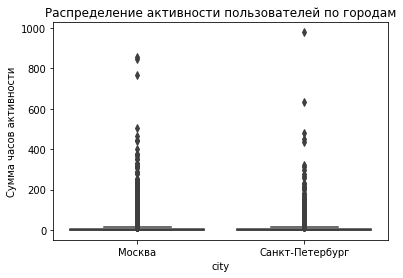

In [17]:
# Визуализируем
sns.boxplot(x='city', y='hours', data=yandex_knigi)
plt.title('Распределение активности пользователей по городам')
plt.ylabel('Сумма часов активности')
plt.show()

In [18]:
# Функция для удаления выбросов в группах А и В
def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return series[(series >= lower_bound) & (series <= upper_bound)]

# Применяем отдельно для каждого города
spb_clean = remove_outliers(spb)
moscow_clean = remove_outliers(moscow)

In [19]:
# Проверяем новые размеры выборок
display("Размеры выборок после удаления выбросов:")
display(f"СПб: {len(spb_clean)}")
display(f"Москва: {len(moscow_clean)}")

# Новая статистика
display("\nСтатистика по Санкт-Петербургу (без выбросов):")
display(spb_clean.describe())
display("\nСтатистика по Москве (без выбросов):")
display(moscow_clean.describe())

'Размеры выборок после удаления выбросов:'

'СПб: 1960'

'Москва: 5334'

'\nСтатистика по Санкт-Петербургу (без выбросов):'

count    1960.000000
mean        2.026857
std         3.267201
min         0.000025
25%         0.035273
50%         0.473938
75%         2.608367
max        15.200556
Name: hours, dtype: float64

'\nСтатистика по Москве (без выбросов):'

count    5334.000000
mean        2.058279
std         3.183140
min         0.000018
25%         0.039983
50%         0.493403
75%         2.683542
max        14.756737
Name: hours, dtype: float64

Исходя из полученных данных, мы видим, что графики демонстрируют распределение количества часов чтения в Москве и Санкт-Петербурге похожи. Они не показывают явных различий в центральных тенденциях и разбросе данных, это поддерживает вывод о том, что активность пользователей в обоих городах не отличается.
Исходя из данных графика и учитывая статистические показатели, мы видим, что на графике 'Распределение групп A и B по активности пользователей' визуально нет сильных перекосов и они сопоставимы, мы можем сравнивать эти группы.

Проверим гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. 

Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [20]:
# Односторонний t‑тест: проверяем, что среднее в group_b > group_a

t_stat, p_value = stats.ttest_ind(group_b, group_a, equal_var=True, alternative='greater')

print(f"t‑статистика: {t_stat}")
print(f"p‑значение: {p_value}")  

alpha = 0.05

if p_value > alpha:
    display(f"pvalue = {p_value} > {alpha}.")
    display("Нет оснований отвергать H0.")
else:
    display(f"pvalue = {p_value} <= {alpha}.")  
    display("Данные свидетельствуют в пользу H1.")

t‑статистика: -0.4174122942907679
p‑значение: 0.661806320348442


'pvalue = 0.661806320348442 > 0.05.'

'Нет оснований отвергать H0.'

## 3. Аналитическая записка


Мы использовали t-теста Стьюдента с уровнем значимости alpha = 0.05.
pvalue = 0.661806320348442 (pvalue > alpha).

Исходя из результатов теста, можно сделать вывод, что нет оснований отвергать нулевую гипотезу H0, а это означает, что средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

В качествы причины можно указать, что и Москва, и Санкт-Петербург являются крупными городами-миллиониками, в которых живут интелегнтные люди, интересующиеся литературой.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Цели исследования.



Цель: провести оценку результатов A/B-теста. Проверить гипотезу о том, что после разработки новой версии сайта интернет-магазина, увеличится количество пользователей, которые совершают покупки.

Задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## 2. Загрузим данные, оценим их целостность.


In [21]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [22]:
# Загрузка данных
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
participants

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
...,...,...,...,...
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC
14522,FFF28D02B1EACBE1,B,recommender_system_test,PC
14523,FFF28D02B1EACBE1,B,interface_eu_test,PC


In [23]:
events = pd.read_csv(
    'https://code.s3.yandex.net/datasets/ab_test_events.zip',
    parse_dates=['event_dt'],
    low_memory=False
)

In [24]:
# Изучим первые строки датасетов
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [25]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [26]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [27]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [28]:
# Выделяем пользователей теста interface_eu_test
interface_test = participants[participants['ab_test'] == 'interface_eu_test']
print(interface_test)

                user_id group            ab_test   device
0      0002CE61FF2C4011     B  interface_eu_test      Mac
2      001064FEAAB631A1     A  interface_eu_test  Android
4      001E72F50D1C48FA     A  interface_eu_test      Mac
5      002412F1EB3F6E38     B  interface_eu_test      Mac
6      002540BE89C930FB     B  interface_eu_test  Android
...                 ...   ...                ...      ...
14519  FFE600EEC4BA7685     B  interface_eu_test  Android
14520  FFE7FC140521F5F6     A  interface_eu_test       PC
14521  FFEFC0E55C1CCD4F     A  interface_eu_test       PC
14523  FFF28D02B1EACBE1     B  interface_eu_test       PC
14524  FFF58BC33966EB51     A  interface_eu_test  Android

[10850 rows x 4 columns]


In [29]:
display("Количество участников теста:")
interface_test.shape[0]

'Количество участников теста:'

10850

In [30]:
# Проверка распределения по группам, определим количество уникальных значений в столбце group
group_distribution = interface_test['group'].value_counts()

display("Распределение по группам:")
display(group_distribution)

display("Доли пользователей в группах:")
display((group_distribution / group_distribution.sum() * 100).round(2))

'Распределение по группам:'

B    5467
A    5383
Name: group, dtype: int64

'Доли пользователей в группах:'

B    50.39
A    49.61
Name: group, dtype: float64

In [31]:
# Проверка пересечений с другим тестом, посчитаем количества уникальных значений в столбце ab_test для каждого пользователя
user_tests = participants.groupby('user_id')['ab_test'].nunique().reset_index()

# Пользователи, участвующие в нескольких тестах
multi_test_users = user_tests[user_tests['ab_test'] > 1]['user_id']

# Пересечение с рассматриваемым  тестом
intersection = interface_test[interface_test['user_id'].isin(multi_test_users)]

In [32]:
display("Количество пользователей, участвующих в нескольких тестах:")
display(len(multi_test_users))

display("Количество таких пользователей в interface_eu_test:")
display(intersection['user_id'].nunique())

'Количество пользователей, участвующих в нескольких тестах:'

887

'Количество таких пользователей в interface_eu_test:'

887

In [33]:
# Находим пользователей, участвующих в нескольких тестах
users_in_multiple_tests = (
    participants.groupby('user_id')['ab_test']
    .nunique()
    .reset_index())
users_in_multiple_tests

,user_id,ab_test
0,0002CE61FF2C4011,1
1,001064FEAAB631A1,2
2,0010A1C096941592,1
3,001E72F50D1C48FA,1
4,002412F1EB3F6E38,1
...,...,...
13633,FFE600EEC4BA7685,1
13634,FFE7FC140521F5F6,1
13635,FFEFC0E55C1CCD4F,1
13636,FFF28D02B1EACBE1,2


In [34]:
# Выделяем пользователей, участвующих более чем в одном тесте
users_in_multiple_tests = users_in_multiple_tests[
    users_in_multiple_tests['ab_test'] > 1]['user_id']
users_in_multiple_tests

1        001064FEAAB631A1
8        00341D8401F0F665
23       0082295A41A867B5
38       00E68F103C66C1F7
41       00EFA157F7B6E1C4
               ...       
13576    FEA0C585A53E7027
13582    FEC0BCA6C323872F
13605    FF2174A1AA0EAD20
13610    FF44696E39039D29
13636    FFF28D02B1EACBE1
Name: user_id, Length: 887, dtype: object

In [35]:
# Удаляем пользователей, участвующих более чем в одном тесте
participants_clean = participants[
    ~participants['user_id'].isin(users_in_multiple_tests)]

# Формируем выборку только для нужного теста
interface_test = participants_clean[
    participants_clean['ab_test'] == 'interface_eu_test']

In [36]:
interface_test

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android
...,...,...,...,...
14518,FFE5B14BD55C1C5C,A,interface_eu_test,PC
14519,FFE600EEC4BA7685,B,interface_eu_test,Android
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC


In [37]:
display("Количество пользователей после очистки:")
display(interface_test['user_id'].nunique())

display("Распределение по группам:")
display(interface_test['group'].value_counts())

'Количество пользователей после очистки:'

9963

'Распределение по группам:'

B    5011
A    4952
Name: group, dtype: int64

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [38]:
# Получаем список пользователей теста 
test_users = interface_test['user_id'].unique()
test_users 

array(['0002CE61FF2C4011', '001E72F50D1C48FA', '002412F1EB3F6E38', ...,
       'FFE7FC140521F5F6', 'FFEFC0E55C1CCD4F', 'FFF58BC33966EB51'],
      dtype=object)

In [39]:
# Оставляем только события этих пользователей
test_events = events[events['user_id'].isin(test_users)]
test_events

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0
...,...,...,...,...
777479,F80C9BDDEA02E53C,2020-12-30 10:02:43,purchase,4.49
777488,F80C9BDDEA02E53C,2020-12-30 10:03:51,purchase,4.49
777489,F80C9BDDEA02E53C,2020-12-30 10:03:52,product_cart,NaN
778138,6181F3835EBE66BF,2020-12-30 12:10:39,product_cart,NaN


In [40]:
# Проверка результата
display("Количество событий после фильтрации:")
display(test_events.shape[0])

display("Количество уникальных пользователей:")
display(test_events['user_id'].nunique())

display("Распределение типов событий:")
display(test_events['event_name'].value_counts())

'Количество событий после фильтрации:'

73815

'Количество уникальных пользователей:'

9963

'Распределение типов событий:'

login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: event_name, dtype: int64

- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

(Лайфтайм пользователя — это период времени, в течение которого пользователь взаимодействует с продуктом, сервисом или приложением.) 

In [41]:
# Выделяем дату регистрации каждого пользователя
registration = test_events[test_events['event_name'] == 'registration'][['user_id', 'event_dt']]
registration = registration.rename(columns={'event_dt': 'registration_dt'}) # Переименовываем столбец в registration_dt
registration

,user_id,registration_dt
64672,5F506CEBEDC05D30,2020-12-06 14:10:01
64946,51278A006E918D97,2020-12-06 14:37:25
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22
67873,275A8D6254ACF530,2020-12-06 19:36:54
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20
...,...,...
654517,52B5A81EFC31AF1D,2020-12-23 23:44:45
654518,B1D88FBD4BA58E1B,2020-12-23 23:44:47
654581,38CA3A3C4FE3FEFD,2020-12-23 23:47:47
654640,16CCB1C8C4DCF1AF,2020-12-23 23:50:29


In [42]:
# Объединяем с таблицей событий
test_events = test_events.merge(registration, on='user_id', how='left')
test_events

,user_id,event_dt,event_name,details,registration_dt
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20
...,...,...,...,...,...
73810,F80C9BDDEA02E53C,2020-12-30 10:02:43,purchase,4.49,2020-12-07 10:05:54
73811,F80C9BDDEA02E53C,2020-12-30 10:03:51,purchase,4.49,2020-12-07 10:05:54
73812,F80C9BDDEA02E53C,2020-12-30 10:03:52,product_cart,NaN,2020-12-07 10:05:54
73813,6181F3835EBE66BF,2020-12-30 12:10:39,product_cart,NaN,2020-12-07 19:53:20


In [43]:
# Рассчитываем время между датой события и датой регистрации
test_events['lifetime_days'] = (
    test_events['event_dt'] - test_events['registration_dt']
).dt.total_seconds() / (24 * 3600) # total_seconds() преобразует в количество секунд # Количество дней
test_events['lifetime_days']

0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
           ...    
73810    22.997789
73811    22.998576
73812    22.998588
73813    22.678692
73814    22.787049
Name: lifetime_days, Length: 73815, dtype: float64

In [44]:
# Суммарное время пользователей сайта  между датой события и датой регистрации
test_events['lifetime_days'].sum()

198908.80480324072

In [45]:
# Оставляем только события в первые 7 дней активности пользователей
events_7d = test_events[
    (test_events['lifetime_days'] >= 0) &
    (test_events['lifetime_days'] <= 7)
]
events_7d

,user_id,event_dt,event_name,details,registration_dt,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.000000
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.000000
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.000000
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.000000
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.000000
...,...,...,...,...,...,...
73667,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6.507581
73670,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6.508426
73739,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6.370451
73745,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6.371678


In [46]:
display("Распределение событий:")
display(events_7d['event_name'].value_counts())

'Распределение событий:'

login           26644
product_page    15095
registration     9963
purchase         6162
product_cart     5941
Name: event_name, dtype: int64

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [47]:
# Задаём параметры
p1 = 0.30          # базовая конверсия
p2 = 0.33          # ожидаемая конверсия (+3%) по условию
alpha = 0.05       # уровень значимости 
power = 0.8        # мощность теста 

# Рассчитываем размер эффекта
effect_size = proportion_effectsize(p2, p1)

# Рассчитываем необходимый размер выборки на группу (двусторонний тест)
analysis = NormalIndPower()
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    alternative='two-sided'   
)

sample_size = int(sample_size)

display("Необходимый размер выборки на одну группу:")
display(sample_size)

'Необходимый размер выборки на одну группу:'

3761

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [48]:
# Добавляем информацию о группе к событиям
events_7d = events_7d.merge(
    interface_test[['user_id', 'group']],
    on='user_id',
    how='left'
)
events_7d

,user_id,event_dt,event_name,details,registration_dt,lifetime_days,group
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.000000,A
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.000000,A
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.000000,B
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.000000,A
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.000000,B
...,...,...,...,...,...,...,...
63800,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6.507581,A
63801,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6.508426,A
63802,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6.370451,A
63803,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6.371678,A


In [49]:
# Выделяем пользователей, совершивших покупку
purchases = events_7d[events_7d['event_name'] == 'purchase']

# Уникальные пользователи с покупкой по группам
purchasers = purchases.groupby('group')['user_id'].nunique().reset_index()
purchasers = purchasers.rename(columns={'user_id': 'purchasers'})
purchasers

,group,purchasers
0,A,1377
1,B,1480


In [50]:
# Общее количество пользователей по группам
total_users = interface_test.groupby('group')['user_id'].nunique().reset_index()
total_users = total_users.rename(columns={'user_id': 'total_users'})
total_users

,group,total_users
0,A,4952
1,B,5011


In [51]:
# Объединяем результаты
conversion = total_users.merge(purchasers, on='group', how='left')
conversion

,group,total_users,purchasers
0,A,4952,1377
1,B,5011,1480


In [52]:
# Заполняем пропуски для дальнейшей работы
conversion['purchasers'] = conversion['purchasers'].fillna(0).astype(int)
conversion

,group,total_users,purchasers
0,A,4952,1377
1,B,5011,1480


In [53]:
# Расчёт конверсии по группам в %
conversion['conversion_rate'] = conversion['purchasers'] / conversion['total_users']*100
display("Конверсии по группам в %:")
conversion

'Конверсии по группам в %:'

,group,total_users,purchasers,conversion_rate
0,A,4952,1377,27.806947
1,B,5011,1480,29.535023


In [54]:
# Рассмотрим изменение конверсии в абсолютном значении (прирост в процентных пунктах)
old_conversion = conversion.loc[0, 'conversion_rate']  # control
new_conversion = conversion.loc[1, 'conversion_rate']  # test
absolute_change_pp = (new_conversion - old_conversion) * 100

print(f"Абсолютное изменение конверсии: {absolute_change_pp:.2f} п. п.")

Абсолютное изменение конверсии: 172.81 п. п.


In [55]:
# Определим, на сколько улутшилась конверсия (в %)
old_value = 0.3  # старое значение метрики (должны быть в %)
new_value = 0.33  # новое значение метрики
improvement_percent = round(100 * ((new_conversion / old_conversion) - 1), 2)

print(f"Метрика улучшилась на {improvement_percent:.2f}%")

Метрика улучшилась на 6.21%


In [56]:
print(
    f'''Конверсия в тестовой группе увеличилась на {round( (new_conversion - old_conversion), 2)} процентных пункта в абсолютном значении 
или на {round(100 * ((new_conversion / old_conversion) - 1), 2)}% в относительном.''')

Конверсия в тестовой группе увеличилась на 1.73 процентных пункта в абсолютном значении 
или на 6.21% в относительном.


## 4. Проведем оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Гипотеза: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

Параметры теста:
название теста: interface_eu_test;
группы: А (контрольная), B (новый интерфейс).

- Нулевая гипотеза H₀: Конверсия зарегистрированных пользователей в покупателей  после упрощения интерфейса в двух группах не различается.

- Альтернативная гипотеза H₁: Конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта будет больше в группе В после упрощения интерфейса, и это различие статистически значимо.

In [57]:
# Получим массив значений
successes = conversion['purchasers'].values   
all = conversion['total_users'].values  

In [58]:
# Расчёт конверсии по группам
conversion['conversion_rate'] = conversion['purchasers'] / conversion['total_users']
display("Конверсии по группам:")
conversion

'Конверсии по группам:'

,group,total_users,purchasers,conversion_rate
0,A,4952,1377,0.278069
1,B,5011,1480,0.295350


In [59]:
# Используем Z-тест (сравнение двух конверский)

stat, p_value_two_sided = proportions_ztest(successes, all)
p_value_one_sided = p_value_two_sided / 2

display({
    'z-статистика': stat,
    'p-value (односторонний)': p_value_one_sided
})

# Проверка гипотезы

alpha = 0.05 # Уровень значимости

if (p_value_one_sided < alpha) and (conversion.loc[1, 'conversion_rate'] > conversion.loc[0, 'conversion_rate']):
    result = "Данные свидетельствуют в пользу Н1: конверсия в группе B статистически значимо выше."
else:
    result = "Не отвергаем H0: статистически значимых различий нет."
display(result)

{'z-статистика': -1.9069651971471773,
 'p-value (односторонний)': 0.028262547212292124}

'Данные свидетельствуют в пользу Н1: конверсия в группе B статистически значимо выше.'

Для анализа изменения интерфейса сайта интернет-магазина BitMotion Kit мы выбрали Z-тест для сравнение двух конверский с уровнем статистической значимости a = 0.05.
  Результат теста p-value (односторонний) = 0.028262547212292124.
  p-value < a, поэтому данные свидетельствуют в пользу Н1: конверсия в группе B статистически значима выше, чем в группе А.
  То есть конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта и будет больше в группе В после упрощения интерфейса. Значит, был достигнут ожидаемый эффект в изменении конверсии.
  Упрощенный интерфейс интернет-магазина будет удобен в использовании и привлекптелен для пользователей и покупателей. Контрольный показатель конверсии составлял зо % до проведения теста, по данным гипотезы конверсия должна была повысится на 3 % (т.е. 33%). После проведения А/В-анализа, мы сделали вывод, что это верное предположение и цель эксперимента достигнута, ведь  рассматриваемая метрика улучшилась на 6.21 % (в абсолютном выражении изменения 173 п.п.).